In [219]:
import numpy as np
import matplotlib.pyplot as plt
import heapq, math

import os
os.environ["OPENCV_VIDEOIO_MSMF_ENABLE_HW_TRANSFORMS"] = "0"

from __future__ import annotations
import cv2
import numpy as np
from dataclasses import dataclass
from typing import Tuple, Dict, Any, Optional, List

## 1. Warping and cropping Image

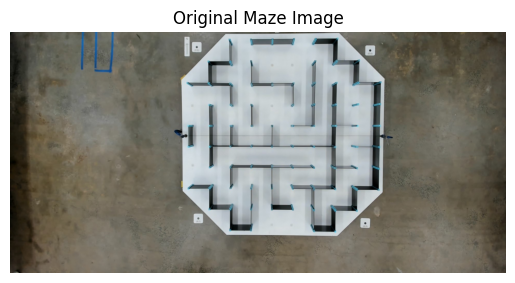

In [220]:
image_path = 'task1.jpg'
image = cv2.imread(image_path)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Maze Image')
plt.axis('off')
plt.show()

## Cam feed

In [221]:
# cam = cv2.VideoCapture(1) # use 0 if your device has no webcam
# ret, image = cam.read()
# cam.release() # release the camera

# if not ret:
#   print("error: couldn't take photo")
#   exit(1)

# plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
# plt.title('Original Maze Image')
# plt.axis('off')
# plt.show()


In [222]:
# # save image
# cv2.imwrite("maze_obs_img.jpg", image)

## Cropper

In [252]:
# step1_warp_board.py
# Step 1: Normalize the top camera view -> square, axis-aligned board image.
# Uses two strategies: (A) board contour; (B) 4 white corner tags. Falls back automatically.



# -------------------------- small helpers --------------------------

def order_corners(pts: np.ndarray) -> np.ndarray:
    """
    Order 4 points as [TL, TR, BR, BL] for a consistent homography.
    pts: (4,2) float32
    """
    pts = pts.astype(np.float32)
    s = pts.sum(axis=1)
    d = np.diff(pts, axis=1).ravel()
    tl = pts[np.argmin(s)]
    br = pts[np.argmax(s)]
    tr = pts[np.argmin(d)]
    bl = pts[np.argmax(d)]
    return np.array([tl, tr, br, bl], dtype=np.float32)

def rotate_bound(img: np.ndarray, angle_deg: float) -> np.ndarray:
    h, w = img.shape[:2]
    cX, cY = w / 2.0, h / 2.0
    M = cv2.getRotationMatrix2D((cX, cY), angle_deg, 1.0)
    cos = abs(M[0, 0]); sin = abs(M[0, 1])
    # compute new bounding dimensions
    nW = int((h * sin) + (w * cos))
    nH = int((h * cos) + (w * sin))
    # adjust the rotation matrix to take into account translation
    M[0, 2] += (nW / 2) - cX
    M[1, 2] += (nH / 2) - cY
    return cv2.warpAffine(img, M, (nW, nH), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)

def dominant_right_angle(img: np.ndarray) -> float:
    """
    Return rotation (degrees) to align the maze to the nearest multiple of 90°.
    Positive means rotate counter-clockwise.
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    edges = cv2.Canny(gray, 60, 160)
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=120, minLineLength=img.shape[1] // 12, maxLineGap=12)
    if lines is None or len(lines) == 0:
        return 0.0
    angs: List[float] = []
    for l in lines:
        x1, y1, x2, y2 = l[0]
        ang = np.degrees(np.arctan2(y2 - y1, x2 - x1))
        # map to [-90, 90)
        ang = ((ang + 90) % 180) - 90
        angs.append(ang)
    if not angs:
        return 0.0
    med = float(np.median(angs))
    nearest90 = round(med / 90.0) * 90.0
    delta = nearest90 - med
    # snap tiny jitter to exactly 0
    if abs(delta) < 0.5:
        delta = 0.0
    return delta

def warp_from_quad(img: np.ndarray, quad: np.ndarray, out_size: int = 1000) -> np.ndarray:
    quad = order_corners(quad.astype(np.float32))
    dst = np.array([[0, 0], [out_size - 1, 0], [out_size - 1, out_size - 1], [0, out_size - 1]], dtype=np.float32)
    H = cv2.getPerspectiveTransform(quad, dst)
    return cv2.warpPerspective(img, H, (out_size, out_size), flags=cv2.INTER_LINEAR)

# -------------------------- Method A: board contour --------------------------

def try_warp_by_board_contour(img: np.ndarray, out_size: int, dbg: Dict[str, Any]) -> Optional[np.ndarray]:
    """
    Detect the bright board as the largest contour and warp its minAreaRect to a square.
    Returns warped image or None if failed.
    """
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    L = lab[:, :, 0]
    # Board is bright: threshold high L; use Otsu on inverted to be robust to lighting
    _, th = cv2.threshold(L, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # Clean up
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=2)

    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    cnt = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    if area < 0.1 * img.shape[0] * img.shape[1]:  # sanity check
        return None

    rect = cv2.minAreaRect(cnt)             # ((cx,cy),(w,h),angle)
    box = cv2.boxPoints(rect)               # 4 corners
    dbg["contour_box"] = box.copy()
    warped = warp_from_quad(img, box, out_size)
    return warped

# -------------------------- Method B: corner tags --------------------------

def try_warp_by_corner_tags(img: np.ndarray, out_size: int, dbg: Dict[str, Any]) -> Optional[np.ndarray]:
    """
    Find 4 small white square tags around the board and warp using their centers.
    Returns warped image or None if failed.
    """
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    # white: low saturation, high value
    mask_white = cv2.inRange(hsv, (0, 0, 180), (180, 70, 255))
    # remove tiny and merge pieces
    mask_white = cv2.morphologyEx(mask_white, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    mask_white = cv2.morphologyEx(mask_white, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=2)

    cnts, _ = cv2.findContours(mask_white, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None

    h, w = img.shape[:2]
    cen = np.array([w / 2.0, h / 2.0])
    cands = []
    for c in cnts:
        area = cv2.contourArea(c)
        if area < 150 or area > 8000:
            continue
        x, y, bw, bh = cv2.boundingRect(c)
        ar = bw / float(bh)
        if ar < 0.6 or ar > 1.6:
            continue
        # must be fairly compact (squares with text)
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.05 * peri, True)
        if len(approx) < 4:  # allow slightly rounded
            continue
        M = cv2.moments(c)
        if M["m00"] == 0:
            continue
        cx = M["m10"] / M["m00"]
        cy = M["m01"] / M["m00"]
        dist = np.linalg.norm(np.array([cx, cy]) - cen)
        cands.append((dist, np.array([cx, cy], dtype=np.float32)))
    # pick the 4 farthest from center (they sit near the corners)
    if len(cands) < 4:
        return None
    cands.sort(key=lambda t: t[0], reverse=True)
    pts = np.array([p for _, p in cands[:4]], dtype=np.float32)
    dbg["tag_points_image"] = pts.copy()

    # Order by corners (TL, TR, BR, BL)
    quad = order_corners(pts)
    warped = warp_from_quad(img, quad, out_size)
    return warped

# -------------------------- Final wrapper --------------------------

@dataclass
class WarpResult:
    warped: np.ndarray
    method: str
    debug: Dict[str, Any]

def warp_maze_board(
    img_bgr: np.ndarray,
    out_size: int = 1000,
    prefer: str = "auto",  # "auto" | "contour" | "tags"
    rotate_to_axis: bool = True,
) -> WarpResult:
    """
    Try method A then B (or vice-versa if prefer="tags").
    Returns a square, axis-aligned board image and diagnostics.
    """
    dbg: Dict[str, Any] = {}

    methods = ["contour", "tags"] if prefer in ("auto", "contour") else ["tags", "contour"]

    warped = None
    used = None
    for m in methods:
        if m == "contour":
            warped = try_warp_by_board_contour(img_bgr, out_size, dbg)
        else:
            warped = try_warp_by_corner_tags(img_bgr, out_size, dbg)
        if warped is not None:
            used = m
            break

    if warped is None:
        raise RuntimeError("Step 1 failed: could not compute a reliable homography using either method.")

    if rotate_to_axis:
        delta = dominant_right_angle(warped)
        dbg["rotation_delta_deg"] = delta
        if abs(delta) > 0.01:
            warped = rotate_bound(warped, delta)
            # After rotation, center-crop back to out_size×out_size (pad/crop)
            h, w = warped.shape[:2]
            y0 = max(0, (h - out_size) // 2)
            x0 = max(0, (w - out_size) // 2)
            warped = warped[y0:y0 + out_size, x0:x0 + out_size].copy()
            if warped.shape[0] != out_size or warped.shape[1] != out_size:
                warped = cv2.resize(warped, (out_size, out_size), interpolation=cv2.INTER_LINEAR)

    return WarpResult(warped=warped, method=used or "unknown", debug=dbg)


    # ap.add_argument("--size", type=int, default=1000, help="Output square size (pixels)")
    # ap.add_argument("--prefer", choices=["auto", "contour", "tags"], default="auto", help="Prefer a method; still falls back")
    # ap.add_argument("--no-rotate", action="store_true", help="Disable auto axis alignment")

if image is None:
    raise SystemExit(f"Could not read image")

res = warp_maze_board(image, out_size=1200, prefer="auto")
# cv2.imwrite(args.out, res.warped)

print(f"[OK] warped |  method={res.method}  rotation={res.debug.get('rotation_delta_deg', 0):.2f}°")


[OK] warped |  method=contour  rotation=0.51°


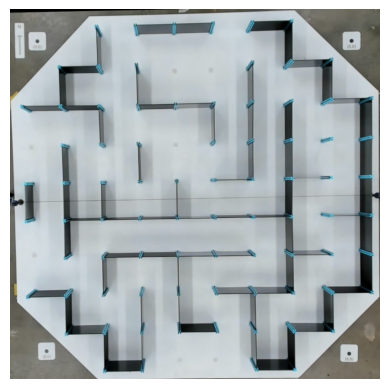

In [253]:
plt.imshow(cv2.cvtColor(res.warped, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## 2. Normalizing image brightness

In [254]:

def _solid_board_mask(bgr):
    """Intensity-only board silhouette (no holes)."""
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    L = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(lab[:,:,0])
    th = cv2.adaptiveThreshold(L, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY, 51, -10)
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(L, np.uint8)
    if cnts:
        cv2.drawContours(mask, [max(cnts, key=cv2.contourArea)], -1, 255, -1)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9,9),np.uint8), 1)
    return mask

def standardize_brightness_to_floor(bgr,
                                    target_L=240,         # desired floor lightness (0–255)
                                    ab_thresh=12,         # how “neutral” a/b must be to count as white
                                    erode_frac=0.015,     # stay away from walls/edges
                                    q=95,                 # use this percentile of floor pixels as reference
                                    alpha_clip=(0.6,1.8), # clamp scale to avoid extremes
                                    return_alpha=False):
    """
    Scale only the Lab L* channel so that the white floor reaches target_L.
    Works with variable lighting; no HSV used.
    """
    H, W = bgr.shape[:2]
    board = _solid_board_mask(bgr)

    # avoid edges so we sample clear floor
    k = max(1, int(erode_frac * min(H, W))) | 1
    board_eroded = cv2.erode(board, np.ones((k, k), np.uint8), 1)

    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    L, a, b = lab[:,:,0], lab[:,:,1], lab[:,:,2]

    # "white" = near-neutral a/b (OpenCV Lab has 128 as neutral)
    white = (np.abs(a-128) <= ab_thresh) & (np.abs(b-128) <= ab_thresh) & (board_eroded > 0)

    # robust reference lightness
    floor_vals = L[white]
    if floor_vals.size < 500:            # fallback: use bright part of board if white sample is tiny
        floor_vals = L[board_eroded > 0]
    ref = float(np.percentile(floor_vals, q))

    # scale factor to hit target_L
    alpha = np.clip(target_L / max(1.0, ref), alpha_clip[0], alpha_clip[1])

    Ln = np.clip(L * alpha, 0, 255)
    lab[:,:,0] = Ln
    out = cv2.cvtColor(lab.astype(np.uint8), cv2.COLOR_LAB2BGR)
    return (out, float(alpha)) if return_alpha else out


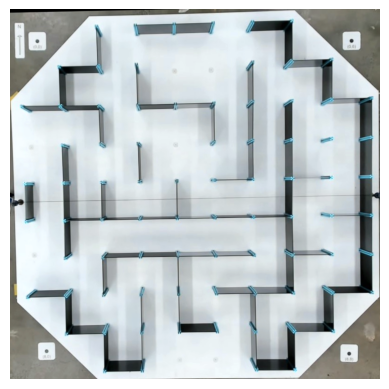

In [255]:

# Or normalize the warped board directly (works too)
warped_norm = standardize_brightness_to_floor(res.warped)


plt.imshow(cv2.cvtColor(warped_norm, cv2.COLOR_BGR2RGB))
# plt.title('Warped Maze Image')
plt.axis('off')
plt.show()


## 3. Wall Detection

In [256]:
# Step 2 tunables (adjust only if needed)
N_CELLS = 9

# relative darkness vs board median (in Lab L* after CLAHE)
DELTA_L = 100               # bigger => more walls captured; try 16–24,,  75

# blackhat kernel for dark bars on light background
BLACKHAT_K = 100                # odd number; try 15–21,  3

# cyan highlights (teal end-caps)
CYAN_H = (80, 105)              # OpenCV H in [0,180]
CYAN_S = (40, 255)
CYAN_V = (40, 255)

# morphology
CLOSE_ITERS = 2                 # seals hairline gaps
OPEN_ITERS  = 1                 # removes speckles
DILATE_ITERS = 1                # thickens walls slightly

# remove tiny blobs (area in px) that slip through
MIN_AREA = 120

image_path = 'finall.jpg'
warped_norm = cv2.imread(image_path)

In [257]:

def otsu_on_values(vals_uint8: np.ndarray) -> int:
    """Otsu on a 1D uint8 array; returns threshold in [0..255]."""
    hist = np.bincount(vals_uint8, minlength=256).astype(np.float64)
    prob = hist / hist.sum()
    omega = np.cumsum(prob)
    mu = np.cumsum(prob * np.arange(256))
    mu_t = mu[-1]
    sigma_b2 = (mu_t*omega - mu)**2 / (omega*(1.0 - omega) + 1e-9)
    k = np.nanargmax(sigma_b2)
    return int(k)

def remove_small_components(bin_img: np.ndarray, min_area: int) -> np.ndarray:
    """Keep only connected components with area >= min_area (8-connectivity)."""
    num, labels, stats, _ = cv2.connectedComponentsWithStats(bin_img, connectivity=8)
    keep = np.zeros_like(bin_img)
    for i in range(1, num):  # 0 is background
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            keep[labels == i] = 255
    return keep




In [258]:
def extract_wall_mask_robust(img_bgr,
                             delta_L=DELTA_L,
                             k_bh=BLACKHAT_K,
                             cyan_h=CYAN_H, cyan_s=CYAN_S, cyan_v=CYAN_V,
                             close_iters=CLOSE_ITERS, open_iters=OPEN_ITERS, dilate_iters=DILATE_ITERS,
                             min_area=MIN_AREA,
                             debug=True):
    H, W = img_bgr.shape[:2]

    # --- color spaces
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB); L = lab[:, :, 0]
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # --- board mask (white, low S / high V region), then dilate to include walls
    board0 = cv2.inRange(hsv, (0, 0, 170), (180, 70, 255))
    board = cv2.morphologyEx(board0, cv2.MORPH_CLOSE, np.ones((7,7),np.uint8), 2)
    board = cv2.dilate(board, np.ones((9,9),np.uint8), 1)
    # keep largest component only
    num, labels, stats, _ = cv2.connectedComponentsWithStats(board, connectivity=8)
    if num > 1:
        big = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        board = np.where(labels == big, 255, 0).astype(np.uint8)

    # --- CLAHE to boost contrast on L*
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    L_eq = clahe.apply(L)

    # --- black-hat: dark bars on bright board
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (k_bh, k_bh))
    blackhat = cv2.morphologyEx(L_eq, cv2.MORPH_BLACKHAT, k)

    # Otsu on board-only pixels
    vals = blackhat[board > 0].astype(np.uint8).ravel()
    t_bh = otsu_on_values(vals) if vals.size else 25
    bh_bin = ((blackhat >= t_bh) & (board > 0)).astype(np.uint8) * 255

    # --- relative dark vs board median
    medL = int(np.median(L_eq[board > 0])) if np.any(board) else int(np.median(L_eq))
    dark_rel = ((L_eq <= (medL - delta_L)) & (board > 0)).astype(np.uint8) * 255

    # --- cyan end-caps
    cyan = cv2.inRange(hsv, (cyan_h[0], cyan_s[0], cyan_v[0]), (cyan_h[1], cyan_s[1], cyan_v[1]))

    # --- combine cues and clean
    wall = cv2.bitwise_or(bh_bin, dark_rel)
    wall = cv2.bitwise_or(wall, cyan)
    wall = cv2.bitwise_and(wall, board)

    wall = cv2.morphologyEx(wall, cv2.MORPH_CLOSE, np.ones((5,5),np.uint8), iterations=close_iters)
    wall = cv2.morphologyEx(wall, cv2.MORPH_OPEN,  np.ones((3,3),np.uint8), iterations=open_iters)
    if dilate_iters:
        wall = cv2.dilate(wall, np.ones((3,3),np.uint8), iterations=dilate_iters)

    if min_area > 0:
        wall = remove_small_components(wall, min_area=min_area)

    wall = (wall > 0).astype(np.uint8) * 255

    if debug:
        fig, ax = plt.subplots(2, 3, figsize=(14, 9))
        ax[0,0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)); ax[0,0].set_title("Warped"); ax[0,0].axis("off")
        ax[0,1].imshow(L_eq, cmap="gray"); ax[0,1].set_title("L* (CLAHE)"); ax[0,1].axis("off")
        ax[0,2].imshow(blackhat, cmap="gray"); ax[0,2].set_title(f"Blackhat (k={k_bh}), thr={t_bh}"); ax[0,2].axis("off")
        ax[1,0].imshow(board, cmap="gray"); ax[1,0].set_title("Board mask"); ax[1,0].axis("off")
        ax[1,1].imshow(dark_rel, cmap="gray"); ax[1,1].set_title(f"Relative dark (ΔL={delta_L})"); ax[1,1].axis("off")
        ax[1,2].imshow(cv2.bitwise_or(wall, 0), cmap="gray"); ax[1,2].set_title("Final wall mask"); ax[1,2].axis("off")
        plt.show()

    return wall

def overlay_mask(img_bgr, mask, alpha=0.45):
    ov = img_bgr.copy()
    ov[mask > 0] = (0, 0, 255)
    return cv2.addWeighted(img_bgr, 1 - alpha, ov, alpha, 0)


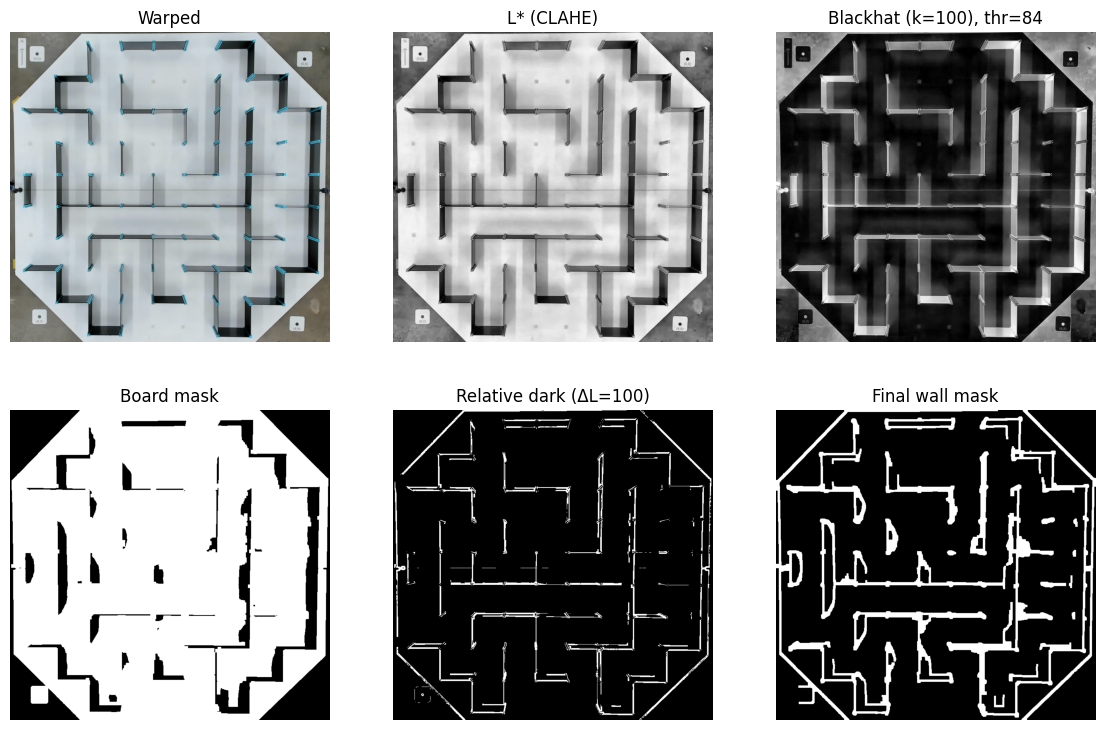

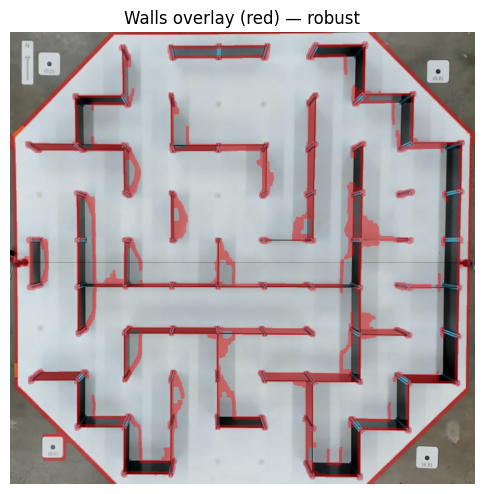

In [259]:
# warped = res.warped.copy()

wall_mask = extract_wall_mask_robust(
    warped_norm,
    delta_L=DELTA_L,
    k_bh=BLACKHAT_K,
    cyan_h=CYAN_H, cyan_s=CYAN_S, cyan_v=CYAN_V,
    close_iters=CLOSE_ITERS, open_iters=OPEN_ITERS, dilate_iters=DILATE_ITERS,
    min_area=MIN_AREA,
    debug=True
)

ov = overlay_mask(warped_norm, wall_mask, alpha=0.40)
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB))
plt.title("Walls overlay (red) — robust")
plt.axis('off')
plt.show()


## 4. Lay down the grid

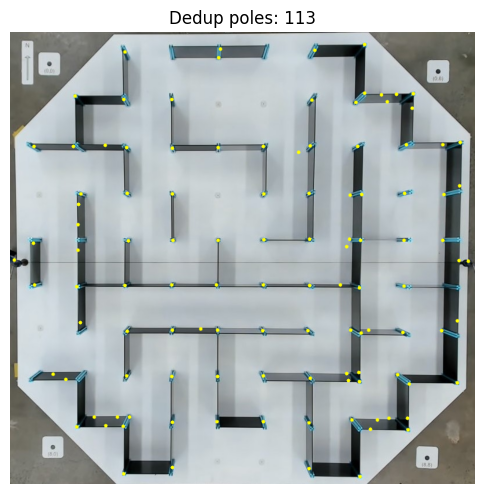

In [260]:
# ==== PARAMETERS ====
N_CELLS = 9                                # -> expect (N+1) x (N+1) grid
# CYAN_H = (40, 110); CYAN_S = (47, 255); CYAN_V = (35, 255)
CYAN_H = (40, 110); CYAN_S = (45, 255); CYAN_V = (35, 255) # CHANGE(Lower) S if not detected
AREA_MIN, AREA_MAX = 10, 2000              # CC size filter for poles
OPEN_ITERS, CLOSE_ITERS = 1, 2             # morphology for pole mask
DEDUP_RADIUS_FRAC = 0.012                  # merge yellow dots closer than this * min(H,W)


def board_mask_from_warped(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    m = cv2.inRange(hsv, (0,0,170), (180,70,255))
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((7,7),np.uint8), 2)
    m = cv2.dilate(m, np.ones((9,9),np.uint8), 1)
    num, lbl, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    if num > 1:
        big = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        m = (lbl == big).astype(np.uint8) * 255
    return m

# --- Cloudy-friendly cyan mask + drop-in pole detector ---


# Wider ranges for low/flat light (OpenCV HSV, H in [0,179])
CYAN_H_RANGES = [(65, 95), (96, 120)]   # greenish-cyan … bluish-cyan
CYAN_S = (30, 255)                      # lower S floor
CYAN_V = (45, 255)                      # allow darker caps

def cyan_mask_cloudy(img_bgr):
    """Union of two cyan hue bands + light morphology."""
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    lo1, hi1 = (CYAN_H_RANGES[0][0], CYAN_S[0], CYAN_V[0]), (CYAN_H_RANGES[0][1], CYAN_S[1], CYAN_V[1])
    lo2, hi2 = (CYAN_H_RANGES[1][0], CYAN_S[0], CYAN_V[0]), (CYAN_H_RANGES[1][1], CYAN_S[1], CYAN_V[1])
    m1 = cv2.inRange(hsv, lo1, hi1)
    m2 = cv2.inRange(hsv, lo2, hi2)
    m  = cv2.bitwise_or(m1, m2)
    m  = cv2.morphologyEx(m, cv2.MORPH_OPEN,  np.ones((3,3),np.uint8), 1)
    m  = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((5,5),np.uint8), 1)
    return m

def detect_cyan_poles(img_bgr, cloudy=True,
                      area_min=10, area_max=2000,
                      open_iters=1, close_iters=2,
                      board_mask_fn=None):
    """
    Returns: pts (Nx2 float32), mask (uint8)
    Drop-in replacement for your old detect_cyan_poles.
    """
    # board mask (reuse your existing helper if present)
    if board_mask_fn is None:
        board_mask_fn = globals().get('board_mask_from_warped', None)
    board_mask = board_mask_fn(img_bgr) if board_mask_fn else np.ones(img_bgr.shape[:2], np.uint8)*255

    # cyan mask
    if cloudy:
        m = cyan_mask_cloudy(img_bgr)
    else:
        # your original single-range fallback
        hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        lo = (int(CYAN_H[0]), int(CYAN_S[0]), int(CYAN_V[0]))
        hi = (int(CYAN_H[1]), int(CYAN_S[1]), int(CYAN_V[1]))
        m  = cv2.inRange(hsv, lo, hi)

    # restrict to board + tidy
    m = cv2.bitwise_and(m, board_mask)
    if open_iters:  m = cv2.morphologyEx(m, cv2.MORPH_OPEN,  np.ones((3,3),np.uint8), open_iters)
    if close_iters: m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((5,5),np.uint8), close_iters)

    # CC -> centroids
    num, labels, stats, cents = cv2.connectedComponentsWithStats(m, connectivity=8)
    pts = []
    for i in range(1, num):
        a = stats[i, cv2.CC_STAT_AREA]
        if area_min <= a <= area_max:
            pts.append((float(cents[i,0]), float(cents[i,1])))
    return np.array(pts, np.float32), m


def dedup_points_radius(pts, radius_px):
    """Greedy radius clustering to merge near-duplicates."""
    if len(pts) == 0: return pts
    order = np.argsort(pts[:,0] + 1e-3*pts[:,1])
    r2 = radius_px*radius_px
    clusters = []
    for p in pts[order]:
        hit = None
        for c in clusters:
            dx, dy = p[0]-c[0], p[1]-c[1]
            if dx*dx + dy*dy <= r2:
                c[2] += p[0]; c[3] += p[1]; c[4] += 1
                c[0], c[1] = c[2]/c[4], c[3]/c[4]
                hit = True; break
        if not hit:
            clusters.append([p[0], p[1], p[0], p[1], 1])  # cx,cy,sumx,sumy,n
    return np.array([[c[0], c[1]] for c in clusters], np.float32)

# --- run on your warped image from Step 1
# warped = warped_norm
pts_raw, poles_mask = detect_cyan_poles(warped_norm)
H, W = warped_norm.shape[:2]
pts = dedup_points_radius(pts_raw, DEDUP_RADIUS_FRAC*min(H,W))

vis = warped_norm.copy()
for (x,y) in pts: cv2.circle(vis, (int(x),int(y)), 3, (0,255,255), -1)
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); plt.title(f"Dedup poles: {len(pts)}"); plt.axis('off'); plt.show()


In [261]:
# Gap-based 1-D clustering (stable, no sklearn)
def cluster_axis(vals, eps_px):
    """Group sorted 1-D values if consecutive gap <= eps_px. Returns (centers, counts)."""
    if len(vals) == 0: return [], []
    vals = np.sort(vals)
    centers, counts = [], []
    start = 0
    for i in range(1, len(vals)):
        if vals[i] - vals[i-1] > eps_px:
            seg = vals[start:i]
            centers.append(np.median(seg)); counts.append(len(seg)); start = i
    seg = vals[start:]
    centers.append(np.median(seg)); counts.append(len(seg))
    return list(centers), list(counts)

def enforce_exact_lines(centers, counts, target, min_spacing_px):
    """Merge closest until <=target, then insert midpoints of largest gaps until ==target."""
    centers = list(centers); counts = list(counts)
    # merge stage
    while len(centers) > target:
        idx = int(np.argmin(np.diff(centers)))
        # weighted average when merging
        c = (centers[idx]*counts[idx] + centers[idx+1]*counts[idx+1]) / (counts[idx]+counts[idx+1])
        centers[idx:idx+2] = [c]
        counts[idx:idx+2]  = [counts[idx]+counts[idx+1]]
    # split stage
    while len(centers) < target:
        diffs = np.diff(centers)
        j = int(np.argmax(diffs)) if diffs.size else 0
        # insert midpoint only if gap is big; otherwise extrapolate at ends
        if diffs.size and diffs[j] > min_spacing_px*0.8:
            newc = 0.5*(centers[j] + centers[j+1])
            centers.insert(j+1, newc); counts.insert(j+1, 0)
        else:
            # pad at ends to maintain monotonicity
            step = min_spacing_px
            if j == 0:
                centers.insert(0, centers[0]-step); counts.insert(0, 0)
            else:
                centers.append(centers[-1]+step); counts.append(0)
        centers = sorted(centers)
    return np.array(centers, int)

# Cluster by axis with tolerances relative to image size
EPS_X = 0.018 * W  # if two pole x's are within ~1.8% of width -> same vertical line
EPS_Y = 0.018 * H  

x_centers, x_counts = cluster_axis(pts[:,0], EPS_X)
y_centers, y_counts = cluster_axis(pts[:,1], EPS_Y)

# Enforce exactly N+1 straight, evenly-spaced lines
approx_cell_w = (max(x_centers)-min(x_centers)) / max(1, len(x_centers)-1)
approx_cell_h = (max(y_centers)-min(y_centers)) / max(1, len(y_centers)-1)
x_lines = enforce_exact_lines(x_centers, x_counts, N_CELLS+1, min_spacing_px=0.6*approx_cell_w)
y_lines = enforce_exact_lines(y_centers, y_counts, N_CELLS+1, min_spacing_px=0.6*approx_cell_h)

print(f"x-lines: {len(x_lines)}, y-lines: {len(y_lines)}")


x-lines: 10, y-lines: 10


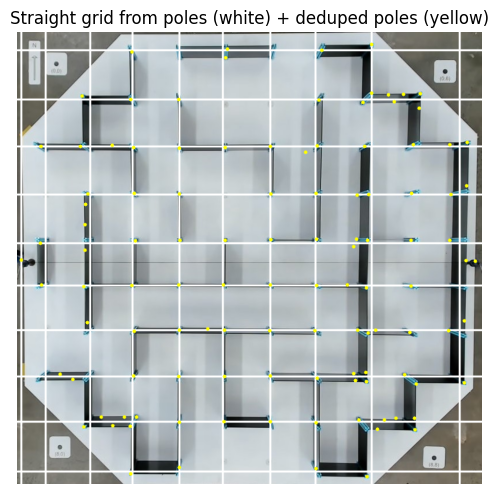

In [262]:
overlay = warped_norm.copy()

# draw straight grid lines
for x in x_lines: cv2.line(overlay, (int(x),0), (int(x),overlay.shape[0]), (255,255,255), 2, cv2.LINE_AA)
for y in y_lines: cv2.line(overlay, (0,int(y)), (overlay.shape[1],int(y)), (255,255,255), 2, cv2.LINE_AA)

# show deduped pole centers too
for (x,y) in pts: cv2.circle(overlay, (int(x),int(y)), 3, (0,255,255), -1)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Straight grid from poles (white) + deduped poles (yellow)")
plt.axis('off'); plt.show()


In [263]:
print(x_lines)
print(y_lines)

[  7  49 126 199 280 355 437 515 612 764]
[ 31 116 197 280 364 437 514 594 672 758]


## 5. Masking the walls with grid

params: {'threshold_u8': 164, 'margin_px': 15, 'thickness_px': 61, 'offsets_px': [0, 0, 0]}
wall counts N/E/S/W: 42 45 39 41


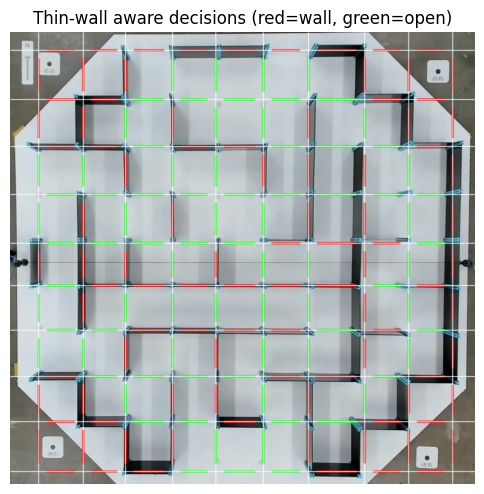

In [285]:
# Thin-wall aware wall detection using ONLY warped + your grid lines (x_lines, y_lines)

# x_lines = [59, 179, 299, 414, 536, 656, 774, 897, 1023, 1147]
# y_lines = [53, 175, 297, 421, 541, 658, 779, 905, 1023, 1147]

x_lines = [  49, 126, 199, 280, 355, 437, 515, 612, 688, 764]
y_lines = [ 31, 116, 197, 280, 364, 437, 514, 594, 672, 758]




# ---- Tunables ----
EDGE_MARGIN_FRAC     = 0.2    # keep samples away from cyan posts
EDGE_THICKNESS_FRAC  = 0.8    # thickness of each sampling strip
OFFSETS_FRAC         = (-0.01, 0.0, +0.01)  # sample 3 strips at ±offsets of cell thickness
W_INTENSITY          = 0     # weight of darkness score
W_GRADIENT           = 5          # weight of orientation-aware gradient score

@dataclass
class MazeWallMap:
    N: int
    wallsN: np.ndarray
    wallsE: np.ndarray
    wallsS: np.ndarray
    wallsW: np.ndarray

def _otsu_uint8(vals_u8):
    h = np.bincount(vals_u8, minlength=256).astype(np.float64)
    p = h / (h.sum() + 1e-9)
    w = np.cumsum(p); m = np.cumsum(p*np.arange(256)); mt = m[-1]
    sb2 = (mt*w - m)**2 / (w*(1-w) + 1e-12)
    return int(np.nanargmax(sb2))

def _strip_stats(img, x1,y1,x2,y2,th):
    """Return q10 (dark) and mean of ROI. Handles axis-aligned segments."""
    H, W = img.shape
    x1=int(round(x1)); y1=int(round(y1)); x2=int(round(x2)); y2=int(round(y2))
    if x1==x2:  # vertical
        x0=max(0,x1-th//2); x1b=min(W,x2+th//2+1)
        y0=max(0,min(y1,y2)); y1b=min(H,max(y1,y2)+1)
    else:       # horizontal
        y0=max(0,y1-th//2); y1b=min(H,y2+th//2+1)
        x0=max(0,min(x1,x2)); x1b=min(W,max(x1,x2)+1)
    roi = img[y0:y1b, x0:x1b]
    if roi.size == 0: return 255.0, 255.0
    q10 = float(np.percentile(roi, 10))   # thin dark bars still show up
    mean = float(np.mean(roi))
    return q10, mean

def classify_walls_thinaware(warped, x_lines, y_lines,
                             edge_margin_frac=EDGE_MARGIN_FRAC,
                             edge_thickness_frac=EDGE_THICKNESS_FRAC,
                             offsets_frac=OFFSETS_FRAC,
                             w_int=W_INTENSITY, w_grad=W_GRADIENT):
    # Prep L* and orientation-aware gradients
    lab = cv2.cvtColor(warped, cv2.COLOR_BGR2LAB)
    L   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(lab[:,:,0])

    # Scharr gives sharp gradients; dx for vertical edges, dy for horizontal
    Gx = cv2.Scharr(L, cv2.CV_32F, 1, 0); Gx = np.abs(Gx)
    Gy = cv2.Scharr(L, cv2.CV_32F, 0, 1); Gy = np.abs(Gy)

    xs = np.sort(np.asarray(x_lines).astype(int))
    ys = np.sort(np.asarray(y_lines).astype(int))
    N  = len(xs) - 1
    assert N == len(ys) - 1

    cell_w = float(np.median(np.diff(xs))); cell_h = float(np.median(np.diff(ys)))
    pitch  = min(cell_w, cell_h)
    thick  = max(2, int(pitch * edge_thickness_frac))
    margin = int(pitch * edge_margin_frac)
    offsets = [int(pitch * o) for o in offsets_frac]

    medL = float(np.median(L[ys[0]:ys[-1], xs[0]:xs[-1]]))

    # collect combined scores
    scores = []
    edges  = []  # (r,c,side,score)

    def edge_score(x1,y1,x2,y2,is_vertical):
        # Evaluate 3 parallel strips and take the max combined score
        best = 0.0
        for off in offsets:
            if is_vertical:
                q10, mean = _strip_stats(L, x1+off, y1, x2+off, y2, thick)
                # darker -> larger (medL - q10); use Gx (normal to vertical edge)
                g_mean = _strip_stats(Gx, x1+off, y1, x2+off, y2, thick)[1]
            else:
                q10, mean = _strip_stats(L, x1, y1+off, x2, y2+off, thick)
                # darker -> larger; use Gy (normal to horizontal edge)
                g_mean = _strip_stats(Gy, x1, y1+off, x2, y2+off, thick)[1]

            dark_score = max(0.0, medL - q10)   # percentile darkness
            comb = w_int*dark_score + w_grad*(g_mean/4.0)  # scale gradient a bit
            best = max(best, comb)
        return best

    for r in range(N):
        for c in range(N):
            xL,xR = xs[c], xs[c+1]
            yT,yB = ys[r], ys[r+1]

            sN = edge_score(xL+margin, yT, xR-margin, yT, is_vertical=False)
            sS = edge_score(xL+margin, yB, xR-margin, yB, is_vertical=False)
            sW = edge_score(xL, yT+margin, xL, yB-margin, is_vertical=True)
            sE = edge_score(xR, yT+margin, xR, yB-margin, is_vertical=True)

            for side, s in (('N',sN),('S',sS),('W',sW),('E',sE)):
                scores.append(s); edges.append((r,c,side,s))

    # Otsu on combined scores
    scores_u8 = np.clip(np.array(scores), 0, 255).astype(np.uint8)
    thr = _otsu_uint8(scores_u8)

    wallsN = np.zeros((N,N), bool); wallsE=wallsN.copy(); wallsS=wallsN.copy(); wallsW=wallsN.copy()
    for (r,c,side,s) in edges:
        is_wall = (s >= thr)
        if side=='N': wallsN[r,c]=is_wall
        elif side=='S': wallsS[r,c]=is_wall
        elif side=='W': wallsW[r,c]=is_wall
        else: wallsE[r,c]=is_wall

    # make shared edges consistent (OR)
    for r in range(N):
        for c in range(N-1):
            e = wallsE[r,c] or wallsW[r,c+1]; wallsE[r,c]=wallsW[r,c+1]=e
    for r in range(N-1):
        for c in range(N):
            e = wallsS[r,c] or wallsN[r+1,c]; wallsS[r,c]=wallsN[r+1,c]=e

    return MazeWallMap(N, wallsN, wallsE, wallsS, wallsW), {"threshold_u8": int(thr),
                                                            "margin_px": int(margin),
                                                            "thickness_px": int(thick),
                                                            "offsets_px": offsets}

# ---- run it and visualize
wallmap, params = classify_walls_thinaware(overlay, x_lines, y_lines)
print("params:", params)
print("wall counts N/E/S/W:", wallmap.wallsN.sum(), wallmap.wallsE.sum(), wallmap.wallsS.sum(), wallmap.wallsW.sum())

viz = warped_norm.copy()
xs = np.sort(np.asarray(x_lines).astype(int))
ys = np.sort(np.asarray(y_lines).astype(int))
margin = params["margin_px"]
for r in range(wallmap.N):
    for c in range(wallmap.N):
        xL,xR = int(xs[c]), int(xs[c+1]); yT,yB = int(ys[r]), int(ys[r+1])
        cv2.line(viz, (xL+margin,yT), (xR-margin,yT), (0,0,255) if wallmap.wallsN[r,c] else (0,255,0), 2, cv2.LINE_AA)
        cv2.line(viz, (xL+margin,yB), (xR-margin,yB), (0,0,255) if wallmap.wallsS[r,c] else (0,255,0), 2, cv2.LINE_AA)
        cv2.line(viz, (xL,yT+margin), (xL,yB-margin), (0,0,255) if wallmap.wallsW[r,c] else (0,255,0), 2, cv2.LINE_AA)
        cv2.line(viz, (xR,yT+margin), (xR,yB-margin), (0,0,255) if wallmap.wallsE[r,c] else (0,255,0), 2, cv2.LINE_AA)

# re-draw the grid (thin white) for context
for x in xs: cv2.line(viz, (int(x),0), (int(x),viz.shape[0]), (255,255,255), 1, cv2.LINE_AA)
for y in ys: cv2.line(viz, (0,int(y)), (viz.shape[1],int(y)), (255,255,255), 1, cv2.LINE_AA)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
plt.title("Thin-wall aware decisions (red=wall, green=open)")
plt.axis('off'); plt.show()


## 6. Logical maze extract

bars: 16px  margin: 7px  connector radius: 11px


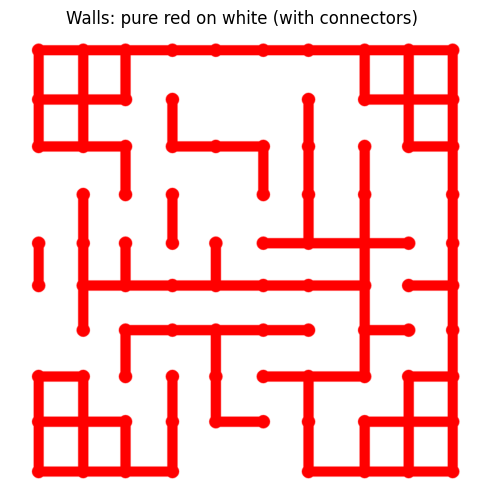

In [286]:
# Red walls on white background WITH CONNECTORS at grid intersections

# ---- tunables ----
DRAW_THICK_FRAC   = 0.22   # wall bar thickness relative to cell size
MARGIN_FRAC       = 0.10   # keep bars a bit away from the posts
CONNECTOR_FRAC    = 0.70   # connector radius as a fraction of bar thickness (0.6–0.9 looks good)
CONNECTOR_SHAPE   = "circle"  # "circle" or "square"

xs = np.sort(np.asarray(x_lines).astype(int))
ys = np.sort(np.asarray(y_lines).astype(int))
N  = wallmap.N

cell_w = float(np.median(np.diff(xs)))
cell_h = float(np.median(np.diff(ys)))
pitch  = min(cell_w, cell_h)

thick  = max(2, int(pitch * DRAW_THICK_FRAC))
margin = int(pitch * MARGIN_FRAC)
cap_r  = max(2, int(thick * CONNECTOR_FRAC))  # connector "radius"

# white canvas
walls_white = np.full_like(warped_norm, 255)  # BGR=white
RED = (0, 0, 255)

def rect_h(x1, x2, y, t, color):  # horizontal bar centered at y
    y1 = int(y - t//2); y2 = int(y + t//2)
    cv2.rectangle(walls_white, (int(x1), y1), (int(x2), y2), color, -1, cv2.LINE_AA)

def rect_v(x, y1, y2, t, color):  # vertical bar centered at x
    x1 = int(x - t//2); x2 = int(x + t//2)
    cv2.rectangle(walls_white, (x1, int(y1)), (x2, int(y2)), color, -1, cv2.LINE_AA)

# 1) draw all wall bars
for r in range(N):
    for c in range(N):
        xL, xR = xs[c], xs[c+1]
        yT, yB = ys[r], ys[r+1]

        if wallmap.wallsN[r, c]: rect_h(xL+margin, xR-margin, yT, thick, RED)
        if wallmap.wallsS[r, c]: rect_h(xL+margin, xR-margin, yB, thick, RED)
        if wallmap.wallsW[r, c]: rect_v(xL, yT+margin, yB-margin, thick, RED)
        if wallmap.wallsE[r, c]: rect_v(xR, yT+margin, yB-margin, thick, RED)

# 2) add connector pads at every grid intersection if any incident edge is a wall
for r in range(N+1):
    for c in range(N+1):
        # does at least one incident edge (among the 4 around this vertex) exist?
        incident = False
        if r < N and c < N and wallmap.wallsN[r, c]: incident = True           # north of SE cell
        if r < N and c < N and wallmap.wallsW[r, c]: incident = True           # west  of SE cell
        if r > 0 and c < N and wallmap.wallsS[r-1, c]: incident = True         # south of NE cell
        if r < N and c > 0 and wallmap.wallsE[r, c-1]: incident = True         # east  of SW cell
        if r < N and c > 0 and wallmap.wallsN[r, c-1]: incident = True         # north of SW cell
        if r > 0 and c < N and wallmap.wallsW[r-1, c]: incident = True         # west  of NE cell
        if r > 0 and c > 0 and wallmap.wallsS[r-1, c-1]: incident = True       # south of NW cell
        if r > 0 and c > 0 and wallmap.wallsE[r-1, c-1]: incident = True       # east  of NW cell

        if incident:
            cx, cy = int(xs[c]), int(ys[r])
            if CONNECTOR_SHAPE == "square":
                cv2.rectangle(walls_white, (cx-cap_r, cy-cap_r), (cx+cap_r, cy+cap_r), RED, -1, cv2.LINE_AA)
            else:  # circle
                cv2.circle(walls_white, (cx, cy), cap_r, RED, -1, cv2.LINE_AA)

print(f"bars: {thick}px  margin: {margin}px  connector radius: {cap_r}px")
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(walls_white, cv2.COLOR_BGR2RGB))
plt.title("Walls: pure red on white (with connectors)")
plt.axis('off'); plt.show()

# optional: save
# cv2.imwrite("walls_red_on_white_with_connectors.png", walls_white)


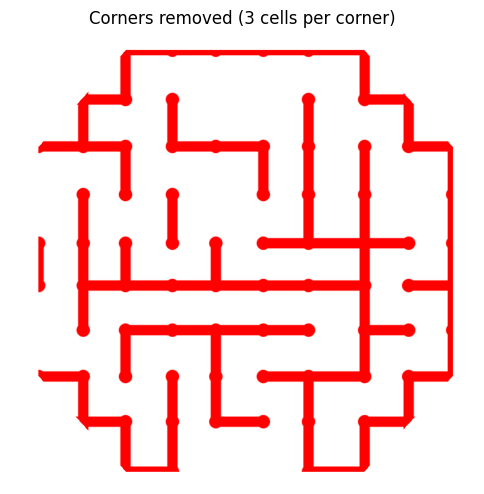

In [287]:
# Remove the 3-cell corner triangles from the walls image (and rebuild collide)
import numpy as np, cv2, matplotlib.pyplot as plt

# how many grid intervals to go in from each corner to define the triangle
# 3 corner cells -> depth of 2 intervals
CORNER_DEPTH = 2   # change to 3, 4... if you ever need a larger cut

def cut_corner_triangles(walls_bgr, x_lines, y_lines, depth=2):
    xs = np.asarray(x_lines, dtype=int)
    ys = np.asarray(y_lines, dtype=int)
    H, W = walls_bgr.shape[:2]

    k = int(depth)
    # triangles in TL / TR / BL / BR corners defined by grid intersections
    tl = np.array([[xs[0],   ys[0]],
                   [xs[k],   ys[0]],
                   [xs[0],   ys[k]]], np.int32)

    tr = np.array([[xs[-1],  ys[0]],
                   [xs[-1-k],ys[0]],
                   [xs[-1],  ys[k]]], np.int32)

    bl = np.array([[xs[0],   ys[-1]],
                   [xs[k],   ys[-1]],
                   [xs[0],   ys[-1-k]]], np.int32)

    br = np.array([[xs[-1],  ys[-1]],
                   [xs[-1-k],ys[-1]],
                   [xs[-1],  ys[-1-k]]], np.int32)

    # build a keep mask = board rectangle minus corner triangles
    keep = np.zeros((H, W), np.uint8)
    cv2.rectangle(keep, (xs[0], ys[0]), (xs[-1], ys[-1]), 255, -1)
    cv2.fillPoly(keep, [tl, tr, bl, br], 0)  # punch out triangles

    # apply to walls: anything outside keep -> set to white
    out = walls_bgr.copy()
    out[keep == 0] = (255, 255, 255)
    return out, keep

# --- apply ---
walls_white, keep_mask = cut_corner_triangles(walls_white, x_lines, y_lines, depth=CORNER_DEPTH)

# quick preview
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(walls_white, cv2.COLOR_BGR2RGB))
plt.title("Corners removed (3 cells per corner)")
plt.axis('off'); plt.show()


## 7. Planning grid and Algorithm (A* with turn cost)

In [288]:
# choose start/end 
# Example: incoming competition values (EDIT these)
comp_start = (8, 6, 'S')   # (row, col, dir)
comp_goal  = (7, 5)        # (row, col)

In [289]:
# ==== params ====
grid_n   = 9          # grid nodes per side
margin  = 120        # used only if x_lines/y_lines aren't available
dilate_px = 1        # safety pad so thin walls still block

import numpy as np, cv2
from collections import deque

# Use your red-on-white render (BGR). We'll build: (a) RGB for plotting, (b) binary mask for collision.
assert 'walls_white' in globals(), "Expected `walls_white` (BGR red on white) to exist."

def make_collision_mask_from_red(walls_bgr, dilate_px=1):
    b,g,r = cv2.split(walls_bgr)
    redish = (r >= 200) & (g <= 30) & (b <= 30)
    mask = (redish.astype(np.uint8) * 255)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3,3),np.uint8), 1)
    if dilate_px > 0:
        mask = cv2.dilate(mask, np.ones((dilate_px, dilate_px), np.uint8), 1)
    return mask

def bresenham_line(x0, y0, x1, y1):
    pts = []
    dx = abs(x1 - x0); dy = -abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx + dy
    while True:
        pts.append((x0, y0))
        if x0 == x1 and y0 == y1: break
        e2 = 2 * err
        if e2 >= dy: err += dy; x0 += sx
        if e2 <= dx: err += dx; y0 += sy
    return pts

def path_clear_mask(mask, x1, y1, x2, y2):
    for (x, y) in bresenham_line(int(x1), int(y1), int(x2), int(y2)):
        if x < 0 or y < 0 or y >= mask.shape[0] or x >= mask.shape[1]:
            return False
        if mask[y, x] != 0:  # wall blocks
            return False
    return True

# Build plotting image + mask
bfsImg  = cv2.cvtColor(walls_white, cv2.COLOR_BGR2RGB)     # pretty display
collide = make_collision_mask_from_red(walls_white, dilate_px=dilate_px)  # logic


In [290]:
# ==== minimal Graph ====
class Node:
    def __init__(self, node_id, x, y): self.id, self.x, self.y = node_id, x, y
    def get_point(self): return (self.x, self.y)

class Graph:
    def __init__(self): self.nodes, self.edges = {}, {}
    def add_node(self, nid, x, y):
        if nid not in self.nodes: self.nodes[nid] = Node(nid, x, y); self.edges[nid] = {}
    def add_edge(self, a, b, w=1): self.edges[a][b]=w; self.edges[b][a]=w

# Build node coordinates either from grid lines (best) or from image bounds (fallback)
def build_grid_nodes(width, height, n, margin, x_lines=None, y_lines=None):
    if x_lines is not None and y_lines is not None and len(x_lines)==n+1 and len(y_lines)==n+1:
        xs = (np.array(x_lines[:-1]) + np.array(x_lines[1:]))/2.0
        ys = (np.array(y_lines[:-1]) + np.array(y_lines[1:]))/2.0
    else:
        xs = np.linspace(margin+1, width - margin,  n)
        ys = np.linspace(margin+1, height - margin, n)
    xs = xs.astype(int); ys = ys.astype(int)

    coords = []
    idmap  = {}
    nid = 0
    for r, y in enumerate(ys):
        for c, x in enumerate(xs):
            coords.append((x,y))
            idmap[(r,c)] = nid
            nid += 1
    return coords, idmap

def add_grid_edges(graph, idmap, coords, n, mask):
    # Connect right & down only (graph is undirected → left/up come for free)
    for r in range(n):
        for c in range(n):
            u = idmap[(r,c)]; x1,y1 = coords[u]
            if c+1 < n:
                v = idmap[(r,c+1)]; x2,y2 = coords[v]
                if path_clear_mask(mask, x1,y1,x2,y2): graph.add_edge(u,v,1)
            if r+1 < n:
                v = idmap[(r+1,c)]; x2,y2 = coords[v]
                if path_clear_mask(mask, x1,y1,x2,y2): graph.add_edge(u,v,1)


In [291]:
h, w = bfsImg.shape[:2]

# Use x_lines/y_lines if you already computed them earlier; else this will fall back to margins
xl = np.sort(np.asarray(x_lines).astype(int)) if 'x_lines' in globals() else None
yl = np.sort(np.asarray(y_lines).astype(int)) if 'y_lines' in globals() else None

coords, idmap = build_grid_nodes(w, h, grid_n, margin, xl, yl)

bfsGraph = Graph()
for nid, (x,y) in enumerate(coords):
    bfsGraph.add_node(nid, x, y)

add_grid_edges(bfsGraph, idmap, coords, grid_n, collide)

print(f"nodes={len(bfsGraph.nodes)}  edges={sum(len(n) for n in bfsGraph.edges.values())//2}")

# use the grid you already built: grid_n, idmap, bfsGraph, etc.

def normalize_rc(r, c, n, origin="topleft", one_indexed=False):
    """Normalize competition coords into our internal (row, col)."""
    if one_indexed:  # flip on if the judge uses 1..n instead of 0..n-1
        r -= 1; c -= 1
    if origin == "bottomleft":  # flip rows if origin is bottom-left (not your figure)
        r = (n - 1) - r
    return r, c

def rc_to_nodeid(r, c, idmap, n):
    assert 0 <= r < n and 0 <= c < n, f"(r,c) out of bounds: {(r,c)} with n={n}"
    return idmap[(r, c)]


# normalize (change one_indexed/origin if their spec differs)
sr, sc = normalize_rc(comp_start[0], comp_start[1], grid_n, origin="topleft", one_indexed=False)
gr, gc = normalize_rc(comp_goal[0],  comp_goal[1],  grid_n, origin="topleft", one_indexed=False)
start_heading = comp_start[2].upper()

aStar_startNode = rc_to_nodeid(sr, sc, idmap, grid_n)
aStar_endNode   = rc_to_nodeid(gr, gc, idmap, grid_n)

print("start node:", aStar_startNode, "goal node:", aStar_endNode, "heading:", start_heading)



nodes=81  edges=83
start node: 78 goal node: 68 heading: S


In [292]:

_ORDER = ['N','E','S','W']

def _heading_between(u, v, coords):
    x1, y1 = coords[u]; x2, y2 = coords[v]
    if y2 < y1: return 'N'
    if y2 > y1: return 'S'
    if x2 > x1: return 'E'
    return 'W'

def _turn_cost(h1, h2):
    if h1 is None or h1 == h2: return 0.0
    i1, i2 = _ORDER.index(h1), _ORDER.index(h2)
    d = (i2 - i1) % 4
    return 1.0 if d in (1,3) else 2.0

def astar_turn(graph, start_id, goal_id, lambda_turn=0.3, start_heading=None):
    """A* with small turn penalty; you can pass the competition start heading."""
    coords = {nid: (graph.nodes[nid].x, graph.nodes[nid].y) for nid in graph.nodes}

    def h(n):
        x, y = coords[n]; gx, gy = coords[goal_id]
        return 0.001 * (abs(x - gx) + abs(y - gy))

    openq = [(0.0, start_id, start_heading)]  # seed with start heading
    g     = {start_id: 0.0}
    prev  = {start_id: (None, start_heading)}
    seen  = set()

    while openq:
        f, u, hu = heapq.heappop(openq)
        if u in seen: 
            continue
        seen.add(u)

        if u == goal_id:
            path = []
            while u is not None:
                path.append(u)
                u, _ = prev[u]
            return path[::-1]

        for v in graph.edges[u].keys():
            hv   = _heading_between(u, v, coords)
            step = 1.0 + lambda_turn * _turn_cost(hu, hv)
            alt  = g[u] + step
            if alt < g.get(v, math.inf):
                g[v] = alt
                prev[v] = (u, hv)
                heapq.heappush(openq, (alt + h(v), v, hv))
    return []



path = astar_turn(bfsGraph, aStar_startNode, aStar_endNode, lambda_turn=0.3)
print(f"Path length: {len(path)}  |  head: {path[:10]}")


Path length: 39  |  head: [78, 69, 70, 61, 62, 53, 52, 43, 44, 35]


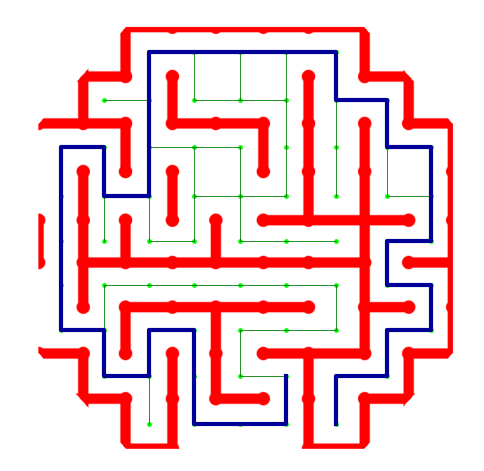

In [293]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(bfsImg); plt.axis('off')

# edges
# for u, nbrs in bfsGraph.edges.items():
#     x1,y1 = bfsGraph.nodes[u].get_point()
#     for v in nbrs.keys():
#         x2,y2 = bfsGraph.nodes[v].get_point()
#         if v > u:  # draw each undirected edge once
#             plt.plot([x1,x2],[y1,y2], color=(0,125/255,0), linewidth=0.6)


# # nodes
# for nid, node in bfsGraph.nodes.items():
#     x,y = node.get_point()
#     plt.scatter(x,y, s=6, color=(0,1,0))

# Map node id -> (row, col) once (you already have idmap the other way)
node_to_rc = {nid: rc for rc, nid in idmap.items()}   # nid -> (r,c)

# 3-cell corner triangles via row/col math (light/HSV independent)
def node_visible_rc(nid, n=grid_n, depth=2):
    """
    Return False for nodes inside the corner triangles of 'depth' grid-intervals.
    depth=2 -> triangles containing 3 cells: (0,0),(0,1),(1,0) etc.
    """
    r, c = node_to_rc[nid]
    d = depth - 1
    # TL, TR, BL, BR triangles
    if (r + c) <= d:                             return False
    if (r + (n - 1 - c)) <= d:                   return False
    if ((n - 1 - r) + c) <= d:                   return False
    if ((n - 1 - r) + (n - 1 - c)) <= d:         return False
    return True


# EDGES: white if either endpoint is in a corner triangle, else green
for u, nbrs in bfsGraph.edges.items():
    x1, y1 = bfsGraph.nodes[u].get_point()
    for v in nbrs.keys():
        if v > u:
            x2, y2 = bfsGraph.nodes[v].get_point()
            in_corner = (not node_visible_rc(u)) or (not node_visible_rc(v))
            color = (1, 1, 1) if in_corner else (0, 125/255, 0)
            plt.plot([x1, x2], [y1, y2], color=color, linewidth=0.6)

# NODES: white if in a corner triangle, else green
for nid, node in bfsGraph.nodes.items():
    color = (1, 1, 1) if (not node_visible_rc(nid)) else (0, 1, 0)
    plt.scatter(node.x, node.y, s=6, color=color)




# BFS path (blue)
if len(path) > 1:
    xs=[bfsGraph.nodes[n].x for n in path]
    ys=[bfsGraph.nodes[n].y for n in path]
    plt.plot(xs, ys, color=(0,0,0.6), linewidth=3, label='BFS Path')


plt.show()


## 8. Movement String Extraction

In [294]:
# --- Convert node-id path -> lowercase commands with repeated 'f' (no counts) ---

# uses: path, idmap, start_heading
node_to_rc = {nid: rc for rc, nid in idmap.items()}  # nid -> (r,c)

ORDER = ['N','E','S','W']  # internal headings stay uppercase

def _turn_cmds_lower(cur_h, next_h):
    if cur_h == next_h: return []
    d = (ORDER.index(next_h) - ORDER.index(cur_h)) % 4
    if d == 1:  return ['r']        # right 90
    if d == 2:  return ['r','r']    # 180 -> rr
    return ['l']                    # left 90

def _delta_to_heading(dr, dc):
    if   (dr, dc) == (-1, 0): return 'N'
    elif (dr, dc) == ( 1, 0): return 'S'
    elif (dr, dc) == ( 0, 1): return 'E'
    elif (dr, dc) == ( 0,-1): return 'W'
    else: raise ValueError(f"Non-adjacent step in path: dr={dr}, dc={dc}")

def path_to_commands_lower(path, node_to_rc, start_heading='N'):
    if len(path) < 2: return []
    cmds = []
    h = start_heading.upper()

    r0, c0 = node_to_rc[path[0]]
    r1, c1 = node_to_rc[path[1]]
    step_h = _delta_to_heading(r1 - r0, c1 - c0)
    cmds += _turn_cmds_lower(h, step_h)
    h = step_h
    run = 1

    for i in range(1, len(path) - 1):
        rA, cA = node_to_rc[path[i]]
        rB, cB = node_to_rc[path[i+1]]
        step_h = _delta_to_heading(rB - rA, cB - cA)
        if step_h == h:
            run += 1
        else:
            cmds += ['f'] * run     # emit repeated f's
            cmds += _turn_cmds_lower(h, step_h)
            h = step_h
            run = 1

    cmds += ['f'] * run             # flush final forward run
    return cmds

# run it
commands = path_to_commands_lower(path, node_to_rc, start_heading=start_heading)
print("Commands list:", commands)
print("Command string (spaced):", " ".join(commands))
print("Command string (compact):", "".join(commands))


Commands list: ['r', 'r', 'f', 'r', 'f', 'l', 'f', 'r', 'f', 'l', 'f', 'l', 'f', 'r', 'f', 'r', 'f', 'l', 'f', 'f', 'l', 'f', 'r', 'f', 'l', 'f', 'r', 'f', 'l', 'f', 'f', 'f', 'f', 'l', 'f', 'f', 'f', 'r', 'f', 'r', 'f', 'l', 'f', 'l', 'f', 'f', 'f', 'f', 'l', 'f', 'r', 'f', 'l', 'f', 'l', 'f', 'r', 'f', 'r', 'f', 'f', 'l', 'f', 'f', 'l', 'f']
Command string (spaced): r r f r f l f r f l f l f r f r f l f f l f r f l f r f l f f f f l f f f r f r f l f l f f f f l f r f l f l f r f r f f l f f l f
Command string (compact): rrfrflfrflflfrfrflfflfrflfrflfffflfffrfrflflfffflfrflflfrfrfflfflf
